# Create files with perturbed temperatures

In [1]:
%load_ext autoreload
%autoreload 2

In [33]:
import os
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [37]:
# Directories
data_path="/media/NAS2/ISMIP7/share_with_modellers"

In [57]:
# Load Climatology file

dpath=os.path.join( data_path,"climatology","v3","zhou_annual_06_nov")
outpath=os.path.join( data_path,"parameterisations","meltMIP")
#filename = "OI_Climatology_ismip8km_60m_tf_extrap.nc"
#variable = "tf"
filename = "OI_Climatology_ismip8km_60m_thetao_extrap.nc"
variable = 'thetao'


background_file = xr.load_dataset(os.path.join(dpath, filename))


In [58]:
# Create perturbation and safe file

for perturbation in [0.5, 1.0, 2.0, 4.0]:
    print(perturbation)
    perturbed_file = background_file.copy(deep=True)
    perturbed_file[variable] = perturbed_file[variable] + perturbation

    output_file= os.path.join(outpath, f"{Path(filename).stem}_perturbation"+str(perturbation)+"K.nc")
    print((perturbed_file[variable] - background_file[variable]).mean(dim=['x','y','z']))
    # safe to dataset
    perturbed_file.to_netcdf(output_file)


0.5
<xarray.DataArray 'thetao' ()> Size: 4B
array(0.5, dtype=float32)
1.0
<xarray.DataArray 'thetao' ()> Size: 4B
array(1., dtype=float32)
2.0
<xarray.DataArray 'thetao' ()> Size: 4B
array(2., dtype=float32)
4.0
<xarray.DataArray 'thetao' ()> Size: 4B
array(4., dtype=float32)


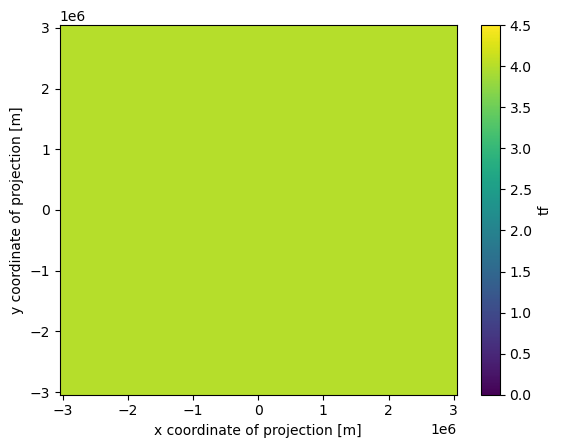

In [50]:
plt.figure()
(perturbed_file[variable] - background_file[variable]).sel(z=slice(0,-100000) ).mean(dim=['z']).plot(vmin=0, vmax=4.5)